In [ ]:
# mount the data from google drive
from google.colab import drive
from google.colab import files
drive.mount("/content/drive")

# navigate to the project folder
%cd drive/MyDrive/projects/CVPR

Mounted at /content/drive
/content/drive/MyDrive/projects/CVPR


In [ ]:
ls ms-coco/

coco_ann2017.zip            coco_train2017.zip  depth/          json-files/
coco-freeview-fixation.csv  coco_val2017.zip    fixations/      old-coco/
coco-images/                deepgaze/           images-by-cat/  stuffthingmaps_trainval2017.zip


In [ ]:
import numpy as np
import pandas as pd

def map_fixations_to_array(df, array_shape, unit_type = 'count'):
    """
    Maps duration values from a DataFrame onto a 2D NumPy array at specified x, y coordinates.

    Parameters:
    df (pd.DataFrame): A DataFrame containing 'x', 'y', and 'duration' columns.
    array_shape (tuple): A tuple representing the shape of the output array (height, width).

    Returns:
    np.ndarray: A 2D NumPy array with duration values mapped at the specified coordinates.
    """
    # Initialize a 2D array with zeros
    fixation_array = np.zeros(array_shape)

    # Loop through each row in the DataFrame
    for _, row in df.iterrows():
        x, y, duration = int(row['x']), int(row['y']), row['duration']

        # Ensure x, y are within bounds
        if 0 <= x < array_shape[1] and 0 <= y < array_shape[0]:
          if unit_type == 'duration':
            fixation_array[y, x] += duration
          else:
            fixation_array[y, x] += 1

    return fixation_array


def bethonio_gaussian(img, fc=6):
    """Gaussian low-pass filter with circular boundary conditions.
         Adapted from MATLAB function by Antonio Torralba (1999).
         See https://github.com/cvzoya/saliency/blob/master/code_forMetrics/antonioGaussian.m

    Parameters
    ----------
    img = input image
    fc = cut-off frequency (-6dB)
    gf = gaussian filter

    Returns
    -------
    BF = filtered image

    NOTE: If the image is not square, there may be some boundary artifacts
    do to zero padding.
    """

    # check if array has a color channel
    if img.ndim > 2:
        sn, sm, c = img.shape

    else:
        sn, sm = img.shape
        c = 0

    n = np.amax([sn, sm])
    n= n + np.remainder(n,2)
    n = 2**(math.ceil(math.log2(n)))

    # make frequencies
    [fx, fy] = np.mgrid[0:n, 0:n]
    fx=fx-n/2
    fy=fy-n/2

    #convert cut off frequency into gaussian width:
    sigma=fc/math.sqrt(math.log(2))

    #compute transfer function of gaussian filter:
    gf = np.exp(-(np.power(fx,2) + np.power(fy, 2))/(sigma**2))
    gf = np.fft.fftshift(gf)

    # convolve (in fourier domain) each color band:
    if c > 0:
        BF = np.zeros((n, n, c))

        for i in range(c):
            BF[:,:,i] = np.fft.ifft2(
                    np.fft.fft2(
                        img[:, :, i], s=(n, n))*gf).real
        BF = BF[0:sn, 0:sm, :]

    # if no color channel
    else:
        BF = np.zeros((n, n))
        BF[:,:] = np.fft.ifft2(
                np.fft.fft2(
                    img[:, :], s=(n, n))*gf).real
        BF = BF[0:sn, 0:sm]

    return BF

In [ ]:
# load in fixation csv
df = pd.read_csv('ms-coco/coco-freeview-fixation.csv')
df

,Unnamed: 0,image_name,subject,condition,split,fixOnTarget,correct,X,Y,T,fixation_index
0,0,000000128398.jpg,101,freeview,train,False,1,821.5,559.2,316.0,0
1,1,000000128398.jpg,101,freeview,train,False,1,957.1,557.7,148.0,1
2,2,000000128398.jpg,101,freeview,train,False,1,933.4,531.1,123.0,2
3,3,000000128398.jpg,101,freeview,train,False,1,748.6,525.6,224.0,3
4,4,000000128398.jpg,101,freeview,train,False,1,530.2,561.4,445.0,4
...,...,...,...,...,...,...,...,...,...,...,...
665000,665000,000000019635.jpg,110,freeview,train,False,1,288.1,471.3,262.0,11
665001,665001,000000019635.jpg,110,freeview,train,False,1,277.1,468.4,304.0,12
665002,665002,000000019635.jpg,110,freeview,train,False,1,257.2,488.9,250.0,13
665003,665003,000000019635.jpg,110,freeview,train,False,1,284.4,495.9,219.0,14


In [ ]:
df = df[df['fixation_index']!=0]
df = df.loc[(df['X'] < 1680) & (df['Y'] < 1050)]
df[['x', 'y', 'duration']] = df[['X', 'Y', 'T']].astype(int)
image_list = df.image_name.unique()
for image in image_list:
  print(image)
  cdf = df[df['image_name']==image]
  fix_array = map_fixations_to_array(cdf, (1050,1680), unit_type=int)
  np.save(str('/content/drive/MyDrive/projects/CVPR/ms-coco/fixations/' + image[:-4] + '.npy'), fix_array)

000000128398.jpg
000000316561.jpg
000000019544.jpg
000000573206.jpg
000000092217.jpg
000000350270.jpg
000000062348.jpg
000000263924.jpg
000000053425.jpg
000000580685.jpg
000000536127.jpg
000000353511.jpg
000000553554.jpg
000000496294.jpg
000000056828.jpg
000000079634.jpg
000000498125.jpg
000000273103.jpg
000000448077.jpg
000000541029.jpg
000000107147.jpg
000000544451.jpg
000000065427.jpg
000000503996.jpg
000000566752.jpg
000000530905.jpg
000000131595.jpg
000000262962.jpg
000000449394.jpg
000000211326.jpg
000000254882.jpg
000000051047.jpg
000000399488.jpg
000000058864.jpg
000000082775.jpg
000000036417.jpg
000000047949.jpg
000000287289.jpg
000000326210.jpg
000000333842.jpg
000000142970.jpg
000000404296.jpg
000000539216.jpg
000000060360.jpg
000000465457.jpg
000000301232.jpg
000000085404.jpg
000000124995.jpg
000000311087.jpg
000000429312.jpg
000000092288.jpg
000000026454.jpg
000000053491.jpg
000000021190.jpg
000000148067.jpg
000000024823.jpg
000000044878.jpg
000000541147.jpg
000000116577.j

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

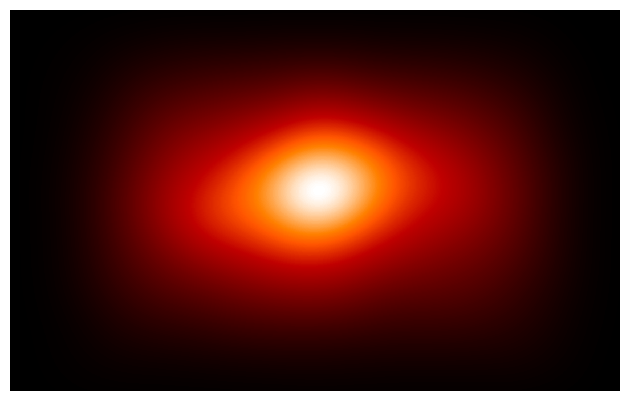

In [ ]:
import matplotlib.pyplot as plt
import math
df = df[df['fixation_index']!=0]
df = df.loc[(df['X'] < 1680) & (df['Y'] < 1050)]
df[['x', 'y', 'duration']] = df[['X', 'Y', 'T']].astype(int)

fv_array = map_fixations_to_array(df, (1050,1680), unit_type='count')
plt.imshow(bethonio_gaussian(fv_array, fc=6), cmap='gist_heat',  interpolation='nearest')
plt.axis('off')
plt.tight_layout()
plt.savefig("figures/coco-fv.png", dpi=1000)
files.download("figures/coco-fv.png")